In [ ]:
import pandas as pd

# Data source and stocks to include
DATA_FILE = "data/AAPL_MSFT_KO_2020-01-01_2026-01-01_adjusted.csv" # should be 'data/DOWNLOADED_DATA.csv'; given in output of downloader.py

# Date boundaries: start included, end excluded
DATA_START = "2020-01-01" # yyyy-mm-dd
TEST_START = "2025-01-01" # yyyy-mm-dd
DATA_END = "2026-01-01" # yyyy-mm-dd

# Portfolio and reporting assumptions
INITIAL_CAPITAL = 100.0 # float
TRADING_DAYS_PER_YEAR = 252 # int

In [2]:
prices = pd.read_csv(
    DATA_FILE,
    index_col=0,
    parse_dates=True,
)

if prices.empty:
    raise ValueError("No prices found for the selected dates.")

if prices.index.has_duplicates:
    raise ValueError("The data contains duplicate dates.")

if prices.isna().any().any():
    raise ValueError("Selected stocks have missing prices.")

prices.head()

,AAPL,MSFT,KO
Date,,,
2020-01-02,72.271538,151.544266,45.141270
2020-01-03,71.568909,149.657257,44.895000
2020-01-06,72.139206,150.044083,44.878574
2020-01-07,71.799919,148.676041,44.533798
2020-01-08,72.954895,151.044174,44.615887


In [3]:
normalised_prices = prices / prices.iloc[0] * 100

normalised_prices.head()

,AAPL,MSFT,KO
Date,,,
2020-01-02,100.000000,100.000000,100.000000
2020-01-03,99.027793,98.754814,99.454448
2020-01-06,99.816896,99.010069,99.418060
2020-01-07,99.347435,98.107335,98.654288
2020-01-08,100.945541,99.670003,98.836136


<Axes: title={'center': 'Normalised stock prices'}, xlabel='Date', ylabel='Value of an initial 100'>

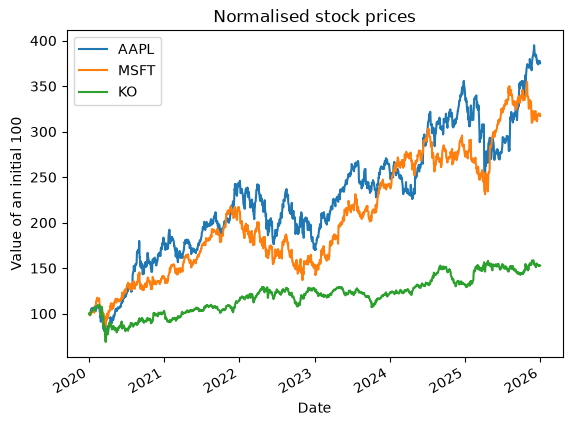

In [4]:
normalised_prices.plot(
    # figsize=(10, 6),
    title="Normalised stock prices",
    ylabel="Value of an initial 100",
    xlabel="Date",
)

In [5]:
daily_returns = prices.pct_change(fill_method=None).dropna()
daily_returns.head(-10)

,AAPL,MSFT,KO
Date,,,
2020-01-03,-0.009722,-0.012452,-0.005456
2020-01-06,0.007969,0.002585,-0.000366
2020-01-07,-0.004703,-0.009118,-0.007682
2020-01-08,0.016086,0.015928,0.001843
2020-01-09,0.021241,0.012493,0.018215
...,...,...,...
2025-12-10,0.005772,-0.027357,0.001712
2025-12-11,-0.002690,0.010260,-0.015667
2025-12-12,0.000899,-0.010218,0.020402


In [6]:
train_returns = daily_returns.loc[
    daily_returns.index < TEST_START
]

test_returns = daily_returns.loc[
    daily_returns.index >= TEST_START
]

if len(train_returns) < 2 or len(test_returns) < 2:
    raise ValueError("Both periods need at least two daily returns.")

print(
    f"Training: {train_returns.index.min().date()} "
    f"to {train_returns.index.max().date()}"
)

print(
    f"Testing:  {test_returns.index.min().date()} "
    f"to {test_returns.index.max().date()}"
)

print(f"Stocks: {len(prices.columns)}")


Training: 2020-01-03 to 2024-12-31
Testing:  2025-01-02 to 2025-12-31
Stocks: 3


In [7]:
annualised_volatility = train_returns.std() * (TRADING_DAYS_PER_YEAR ** 0.5)
correlation = train_returns.corr()
covariance = train_returns.cov()

display(annualised_volatility, correlation, covariance)

AAPL    0.316786
MSFT    0.304972
KO      0.208001
dtype: float64

,AAPL,MSFT,KO
AAPL,1.000000,0.748327,0.439975
MSFT,0.748327,1.000000,0.434174
KO,0.439975,0.434174,1.000000


,AAPL,MSFT,KO
AAPL,0.000398,0.000287,0.000115
MSFT,0.000287,0.000369,0.000109
KO,0.000115,0.000109,0.000172


***

In [8]:
import numpy as np
from scipy.optimize import minimize

covariance = train_returns.cov()

def portfolio_variance(weights):
    return weights @ covariance.to_numpy() @ weights

In [9]:
n_assets = len(covariance.columns)

equal_weights = np.full(n_assets, 1 / n_assets)

constraints = {
    "type": "eq",
    "fun": lambda weights: weights.sum() - 1,
}

bounds = [(0, 1)] * n_assets

In [10]:
result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000},
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_slsqp = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)

# display(optimal_weights.to_frame().style.format("{:.2%}"))

In [11]:
result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="COBYQA",
    bounds=bounds,
    constraints=constraints,
    options={"final_tr_radius": 1e-10, "feasibility_tol": 1e-10, "maxiter": 1000},
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_cobyqa = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)

In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, Bounds, LinearConstraint

cov_matrix = covariance.to_numpy()
n_assets = len(covariance.columns)

equal_weights = np.full(n_assets, 1 / n_assets)

def portfolio_variance(weights):
    return weights @ cov_matrix @ weights

def variance_gradient(weights):
    return 2 * cov_matrix @ weights

def variance_hessian(weights):
    return 2 * cov_matrix

bounds = Bounds(
    np.zeros(n_assets),
    np.ones(n_assets),
)

constraints = LinearConstraint(
    np.ones((1, n_assets)),
    lb=1,
    ub=1,
)

result = minimize(
    portfolio_variance,
    x0=equal_weights,
    method="trust-constr",
    jac=variance_gradient,
    hess=variance_hessian,
    bounds=bounds,
    constraints=constraints,
    options={
        "gtol": 1e-12,
        "xtol": 1e-12,
        "barrier_tol": 1e-12,
        "maxiter": 1000,
    },
)

if not result.success:
    raise RuntimeError(result.message)

optimal_weights_trust_constr = pd.Series(
    result.x,
    index=covariance.columns,
    name="Weight",
)


In [13]:
print("slsqp:")
display(optimal_weights_slsqp.to_frame().style.format("{:.2%}"))

print("cobyqa:")
display(optimal_weights_cobyqa.to_frame().style.format("{:.2%}"))

print("trust-constr:")
display(optimal_weights_trust_constr.to_frame().style.format("{:.2%}"))


slsqp:


,Weight
AAPL,6.65%
MSFT,14.53%
KO,78.82%


cobyqa:


,Weight
AAPL,6.66%
MSFT,14.52%
KO,78.82%


trust-constr:


,Weight
AAPL,6.65%
MSFT,14.53%
KO,78.82%


Wanted to try different methods of minimizing, only these three can handle bounds and equality constraints directly. 

It seems all 3 give the same weights more or less though; will come back to this when testing with multiple stocks at once.

***

In [14]:
test_returns

,AAPL,MSFT,KO
Date,,,
2025-01-02,-0.026236,-0.006928,-0.006746
2025-01-03,-0.002009,0.011396,-0.001455
2025-01-06,0.006739,0.010630,-0.015223
2025-01-07,-0.011388,-0.012808,0.000493
2025-01-08,0.002023,0.005185,0.014300
...,...,...,...
2025-12-24,0.005324,0.002403,0.003435
2025-12-26,-0.001497,-0.000635,-0.003423
2025-12-29,0.001317,-0.001251,0.004150


In [15]:
test_growth = (1 + test_returns).cumprod()
test_growth

,AAPL,MSFT,KO
Date,,,
2025-01-02,0.973764,0.993072,0.993254
2025-01-03,0.971807,1.004389,0.991809
2025-01-06,0.978356,1.015065,0.976711
2025-01-07,0.967215,1.002064,0.977193
2025-01-08,0.969172,1.007260,0.991166
...,...,...,...
2025-12-24,1.098348,1.166358,1.159307
2025-12-26,1.096704,1.165617,1.155339
2025-12-29,1.098148,1.164160,1.160134


In [16]:
comparison_weights = pd.DataFrame({
    "Minimum variance": optimal_weights_slsqp,
    "Equal weight": 1 / len(optimal_weights_slsqp),
})

comparison_weights

,Minimum variance,Equal weight
AAPL,0.066535,0.333333
MSFT,0.145280,0.333333
KO,0.788184,0.333333


In [17]:
portfolio_values = (
    test_growth[comparison_weights.index] @ comparison_weights
) * INITIAL_CAPITAL

,Total return
Minimum variance,15.16%
Equal weight,13.41%


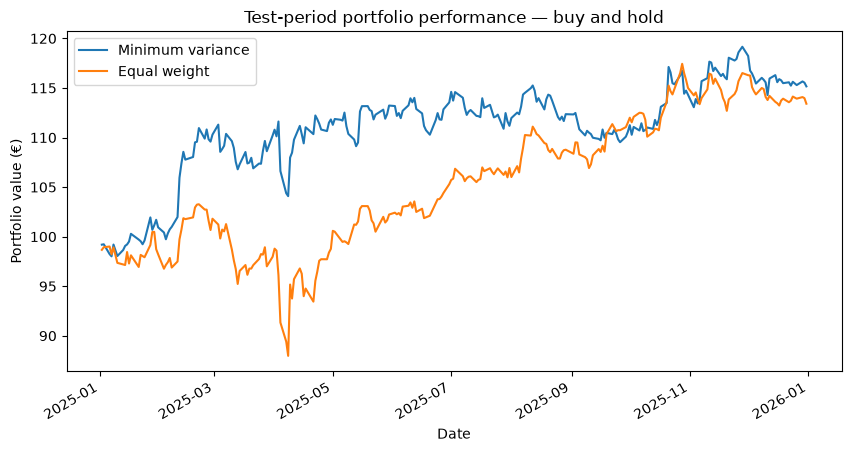

In [18]:
portfolio_values.plot(
    figsize=(10, 5),
    title="Test-period portfolio performance — buy and hold",
    ylabel="Portfolio value (€)",
    xlabel="Date",
)

total_returns = portfolio_values.iloc[-1] / INITIAL_CAPITAL - 1
total_returns.rename("Total return").to_frame().style.format("{:.2%}")

In [19]:
start_date = train_returns.index[-1]

starting_values = pd.DataFrame(
    INITIAL_CAPITAL,
    index=[start_date],
    columns=portfolio_values.columns,
)

portfolio_path = pd.concat([starting_values, portfolio_values])

In [20]:
portfolio_daily_returns = portfolio_path.pct_change(
    fill_method=None
).dropna()

portfolio_volatility = portfolio_daily_returns.std() * (TRADING_DAYS_PER_YEAR ** 0.5)

In [21]:
running_peak = portfolio_path.cummax()
drawdowns = portfolio_path / running_peak - 1

max_drawdown = drawdowns.min()

In [22]:
performance = pd.DataFrame({
    "Total return": total_returns,
    "Annualised volatility": portfolio_volatility,
    "Maximum drawdown": max_drawdown,
})

performance.style.format("{:.2%}")

,Total return,Annualised volatility,Maximum drawdown
Minimum variance,15.16%,14.41%,-6.75%
Equal weight,13.41%,16.23%,-14.81%


<Axes: title={'center': 'Portfolio drawdowns'}, xlabel='Date', ylabel='Decline from previous peak (%)'>

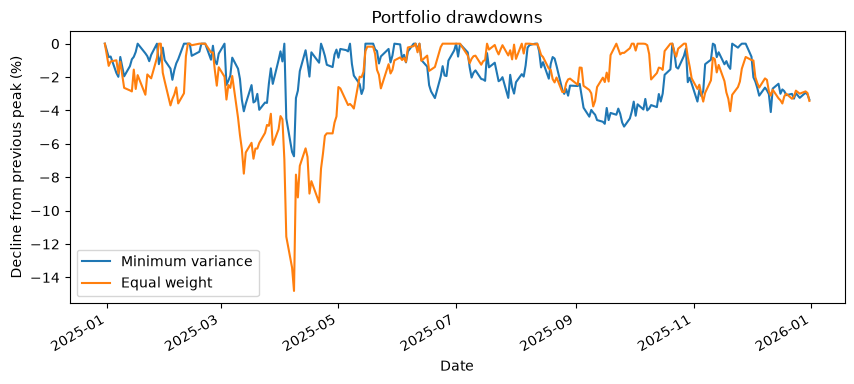

In [23]:
(drawdowns * 100).plot(
    figsize=(10, 4),
    title="Portfolio drawdowns",
    ylabel="Decline from previous peak (%)",
    xlabel="Date",
)